# Get Data

### Connection

postgres connection

In [1]:
import os

from dotenv import load_dotenv
from sqlalchemy import Engine, create_engine
from sqlalchemy.orm import Session
from config import Base

try:
    load_dotenv()

    db_url = os.getenv("DATABASE_URL")

    if not db_url:
        print("Erreur : DATABASE_URL est vide ou non définie.")
        

    if db_url.startswith("postgres://"):
        db_url = db_url.replace("postgres://", "postgresql://", 1)

    engine: Engine = create_engine(db_url)
    Base.metadata.create_all(engine)
    session: Session = Session(engine)

except Exception as e:
    print("DB error:", e)
    raise Exception(e)

if session:
    print("connection succeded")
else :
    print("connection failed")


connection succeded


### Request

SQL get user and practice 

In [2]:
from config import Practice, User
from sqlalchemy import select, text
from sqlalchemy.orm import aliased
from sqlalchemy import func

P2 = aliased(Practice)

subq = (
    select(P2.exercise_id)
    .where(
        P2.user_id == Practice.user_id,
        P2.practice_id != Practice.practice_id,
        P2.practiced_at <= Practice.practiced_at,
        P2.practiced_at >= Practice.practiced_at - text("INTERVAL '1 month'")
    ).scalar_subquery()
)

query = (
    session.query(
        Practice,
        func.array(subq).label("past_exercices")
    )
)

rows = query.all()

### Format data

list data

In [3]:
from datetime import date

def calculate_age(birth_date: date) -> int:
    today = date.today()

    return (
        today.year
        - birth_date.year
        - ((today.month, today.day) < (birth_date.month, birth_date.day))
    )

header = ["user_physical_activity_level", "user_bmi", "user_age", "favorite_exercice_categorie", "exercice name"]

datas = []

for row in rows:
    practice : Practice = row[0]
    past_exercice = row[1]
    exercice = practice.exercise
    user : User = practice.user
    
    data = [
        user.physical_activity_level.lower(), float(user.bmi), calculate_age(user.birthdate), user.favorite_exercice_categorie, exercice.name
    ]
    datas.append(data)

print(datas[0])
print(len(datas))

['sedentary', 19.69, 56, 'Poids du corps', 'Crunch Classique Poids du corps']
44148


Close db connection

In [4]:
session.close()

convert data to pandas dataframe

In [5]:
import pandas as pd

df = pd.DataFrame(datas, columns=header)

### Check data

df

In [6]:
df.shape


(44148, 5)

In [7]:
df.columns


Index(['user_physical_activity_level', 'user_bmi', 'user_age',
       'favorite_exercice_categorie', 'exercice name'],
      dtype='str')

In [8]:
df.info()        # data type + missing value

<class 'pandas.DataFrame'>
RangeIndex: 44148 entries, 0 to 44147
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   user_physical_activity_level  44148 non-null  str    
 1   user_bmi                      44148 non-null  float64
 2   user_age                      44148 non-null  int64  
 3   favorite_exercice_categorie   44148 non-null  str    
 4   exercice name                 44148 non-null  str    
dtypes: float64(1), int64(1), str(3)
memory usage: 1.7 MB


In [9]:
df.head()


,user_physical_activity_level,user_bmi,user_age,favorite_exercice_categorie,exercice name
0,sedentary,19.69,56,Poids du corps,Crunch Classique Poids du corps
1,sedentary,19.69,56,Poids du corps,Squat Classique Poids du corps
2,sedentary,19.69,56,Poids du corps,Squat Classique Poids du corps
3,sedentary,19.69,56,Poids du corps,Développé Nuque à la Barre
4,sedentary,19.69,56,Poids du corps,Développé Décliné à la Smith Machine


In [10]:
df.tail()

,user_physical_activity_level,user_bmi,user_age,favorite_exercice_categorie,exercice name
44143,sedentary,21.01,60,Musculation,Tirage Horizontal aux Haltères
44144,moderate,26.38,43,Musculation,Squat avec Pause à la Barre
44145,moderate,26.38,43,Musculation,Squat avec Pause à la Barre
44146,moderate,26.38,43,Musculation,Squat avec Pause à la Barre
44147,moderate,26.38,43,Musculation,Développé Unilatéral aux Haltères


data repartition

In [11]:
df.describe(include='all')

,user_physical_activity_level,user_bmi,user_age,favorite_exercice_categorie,exercice name
count,44148,44148.000000,44148.000000,44148,44148
unique,3,NaN,NaN,3,249
top,moderate,NaN,NaN,Musculation,Développé Unilatéral au Kettlebell
freq,28586,NaN,NaN,34674,1763
mean,NaN,24.035958,41.145918,NaN,NaN
std,NaN,4.011267,13.454655,NaN,NaN
min,NaN,8.700000,18.000000,NaN,NaN
25%,NaN,21.300000,30.000000,NaN,NaN
50%,NaN,24.090000,41.000000,NaN,NaN
75%,NaN,26.710000,53.000000,NaN,NaN


In [12]:
df.isnull().sum()

user_physical_activity_level    0
user_bmi                        0
user_age                        0
favorite_exercice_categorie     0
exercice name                   0
dtype: int64

cut it too avoid bad readability of diagram

In [13]:
sample_df = df.sample(n=2000, random_state=42)

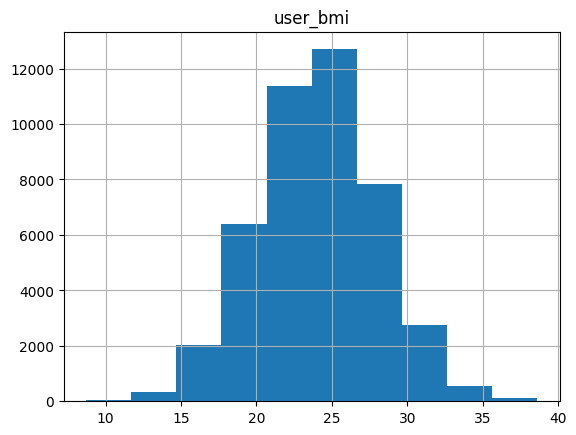

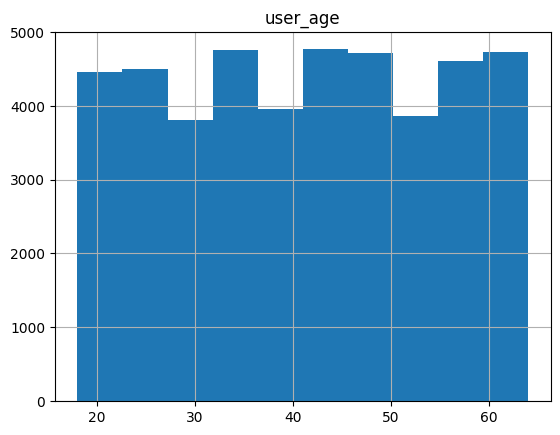

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

columns = ["user_bmi", "user_age"]

for column in columns:
    df[column].hist()
    plt.title(column)
    plt.show()

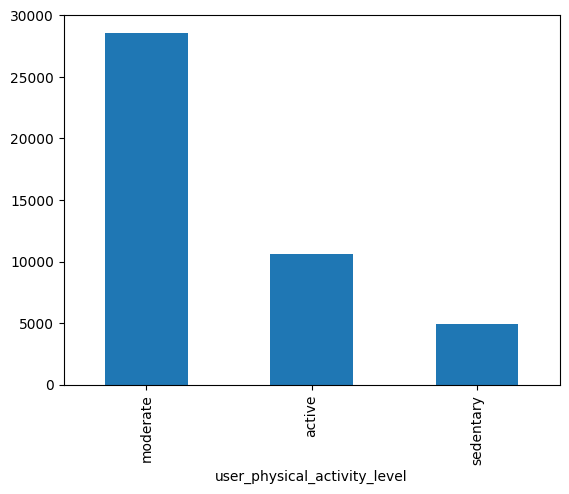

In [15]:
df["user_physical_activity_level"].value_counts().plot(kind="bar")
plt.show()

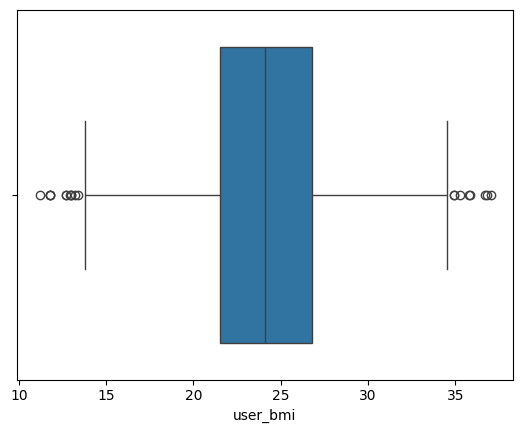

In [16]:
sns.boxplot(x=sample_df["user_bmi"])
plt.show()

In [17]:
print("Age range:", df["user_age"].min(), "to", df["user_age"].max())
print("BMI range:", df["user_bmi"].min(), "to", df["user_bmi"].max())

Age range: 18 to 64
BMI range: 8.7 to 38.61


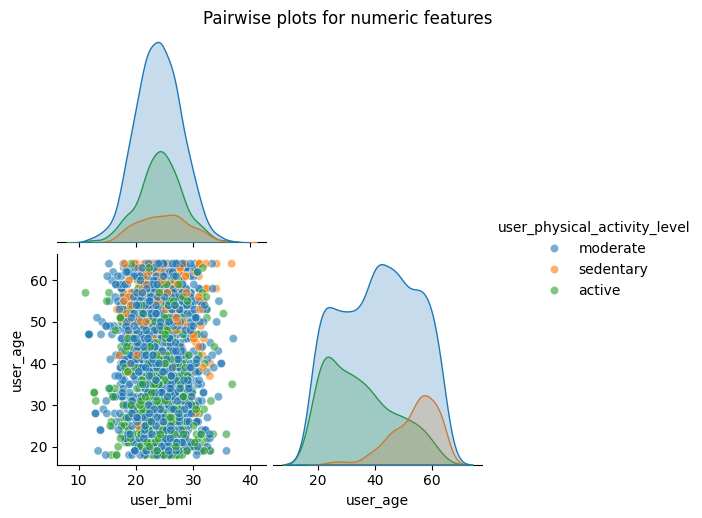

In [18]:
sns.pairplot(
    sample_df,
    vars=["user_bmi", "user_age"],
    hue="user_physical_activity_level",
    palette="tab10",
    corner=True,
    plot_kws={"alpha": 0.6},
)
plt.suptitle("Pairwise plots for numeric features", y=1.02)
plt.show()

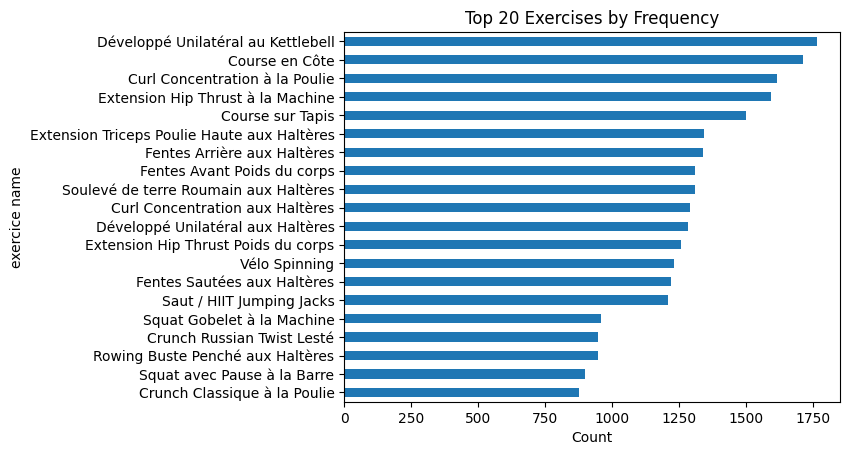

In [19]:
# Exercise frequency and top exercises
exercise_counts = df["exercice name"].value_counts().head(20)
exercise_counts.plot(kind="barh")
plt.title("Top 20 Exercises by Frequency")
plt.xlabel("Count")
plt.gca().invert_yaxis()
plt.show()

### Nettoyage

remove bad data

convert enum to numerical

In [20]:
mapping = {
    "sedentary": 0,
    "moderate": 1,
    "active": 2
}

df["user_physical_activity_level"] = df["user_physical_activity_level"].map(mapping)

print(df["user_physical_activity_level"][0])


0


In [21]:
mapping = {
    "Poids du corps": 0,
    "Musculation": 1,
    "Cardio": 2
}

df["favorite_exercice_categorie"] = df["favorite_exercice_categorie"].map(mapping)

print(df["favorite_exercice_categorie"][0])


0


quick data paranthesis after converting str to int

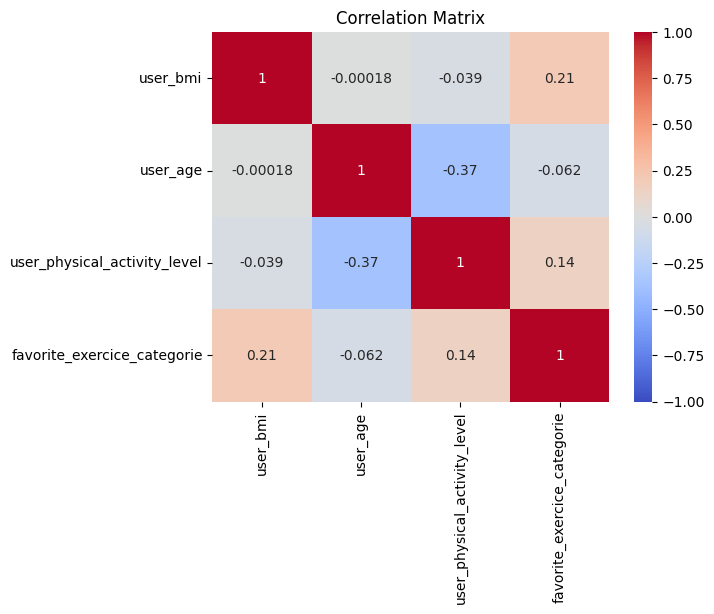

In [22]:
numeric_cols = ["user_bmi", "user_age", "user_physical_activity_level", "favorite_exercice_categorie"]
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

In [23]:
df = df.dropna(subset=['user_bmi', 'user_age', 'exercice name', 'favorite_exercice_categorie', 'user_physical_activity_level'])

print(len(df))

44148


In [24]:
rare_classes = df["exercice name"].value_counts()
rare_classes = rare_classes[rare_classes < 10]

print(rare_classes)

counts = df["exercice name"].value_counts()

df_filtered = df[
    df["exercice name"].isin(counts[counts >= 20].index)
]
print(len(df_filtered["exercice name"].unique()))

exercice name
Curl Pupitre à la Poulie             9
Tirage Vertical à la Barre           8
Développé Militaire au Kettlebell    8
Curl Marteau aux Haltères            7
Tirage Vertical à la Poulie          5
Name: count, dtype: int64
143


### Prepare Data

In [25]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

FEATURES = ['user_physical_activity_level', 'user_bmi', 'user_age', 'favorite_exercice_categorie']
X = df_filtered[FEATURES]
 
le = LabelEncoder()
y  = le.fit_transform(df_filtered['exercice name'])
print('Classes :', le.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Classes : ['Course Fractionné' 'Course Sprint' 'Course en Côte' 'Course sur Tapis'
 'Crunch Bicyclette Poids du corps' 'Crunch Classique Poids du corps'
 'Crunch Classique à la Poulie' 'Crunch Inversé Lesté'
 'Crunch Inversé Poids du corps' 'Crunch Russian Twist Lesté'
 'Crunch Russian Twist Poids du corps' 'Crunch à la Poulie Lesté'
 'Crunch à la Poulie à la Poulie' 'Curl Araignée avec Élastique'
 'Curl Araignée à la Poulie' 'Curl Biceps aux Haltères'
 'Curl Biceps avec Élastique' 'Curl Concentration aux Haltères'
 'Curl Concentration à la Barre' 'Curl Concentration à la Poulie'
 'Curl Marteau à la Barre' 'Curl Marteau à la Poulie'
 'Curl Zottman à la Poulie' 'Développé Arnold au Kettlebell'
 'Développé Arnold aux Haltères' 'Développé Arnold à la Machine'
 'Développé Assis au Kettlebell' 'Développé Assis aux Haltères'
 'Développé Assis à la Barre' 'Développé Couché aux Haltères'
 'Développé Couché à la Barre' 'Développé Couché à la Machine'
 'Développé Décliné aux Haltères' 'Développé

## Train Ai

settings

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, top_k_accuracy_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import numpy as np

model = make_pipeline(
    StandardScaler(),
    LogisticRegression()
)

params = [
    {
        "logisticregression__solver": ["lbfgs"],
        "logisticregression__C": [0.01, 0.1, 1, 10, 100],
        "logisticregression__max_iter": [1000, 2000, 5000]
    },
    {
        "logisticregression__solver": ["saga"],
        "logisticregression__l1_ratio": [0.0, 0.5, 1.0],
        "logisticregression__C": [0.01, 0.1, 1, 10, 100],
        "logisticregression__max_iter": [1000, 2000, 5000]
    }
]

all_labels = np.unique(y)

top5 = make_scorer(
    top_k_accuracy_score,
    k=5,
    response_method="predict_proba",
    labels=all_labels
)

random_search = RandomizedSearchCV(
    model,
    param_distributions= params,
    n_iter=10,
    cv=3,
    scoring=top5,
    random_state=42
)

NameError: name 'np' is not defined

train

In [ ]:
random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_

Check performance

In [ ]:
import numpy as np

probs = best_model.predict_proba(X_test)

top_k = 5

top_k_accuracy = top_k_accuracy_score(y_true=y_test, y_score=probs, k=top_k)

print(top_k_accuracy)


on average where is the right answer

In [ ]:
place = []

sorted_probs =  np.argsort(probs, axis=1)[:, ::-1]

for sorted_prob in range(len(sorted_probs)):
    i = 1
    while sorted_probs[sorted_prob][i-1] != y_test[sorted_prob]:
        i+=1
    place.append(i)

print(np.average(place))

Learning curve

In [ ]:
from sklearn.model_selection import learning_curve


train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X,
    y,
    cv=4,
    scoring=top5,
    train_sizes=[0.5, 0.6, 0.8, 0.9]
)

In [ ]:
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label="Training score")
plt.plot(train_sizes, val_mean, label="Validation score")

plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.title("Learning Curve (Best RandomizedSearchCV Model)")
plt.legend()
plt.show()

Feature importance

In [ ]:
logreg = best_model.named_steps["logisticregression"]

importance = pd.Series(
    logreg.coef_[0],
    index=X.columns
)

importance = importance.sort_values(key=np.abs, ascending=False)

print(importance)

The data has few extreme BMI below 15 above 30 most sedentary user are 40 up so we should check how it behave with those

the general ai is at around 26 and on average the expected "answer" is in whithin the 17 range but the ai is a recomendation it doesn't give a one true answer but a fitting answer 

the learning curve are close so the model seem to be fine with data not in training but the ai accuracy is low but as previously mentioned there isn't realy an answer 

the model could integrade user experiance once we have it

In [ ]:
import joblib, os

os.makedirs('../models', exist_ok=True)
joblib.dump(best_model, '../models/model.pkl')
joblib.dump(le,  '../models/encoder.pkl')
print('models/model.pkl and models/encoder.pkl created')